## Plot the corner plot

In [4]:
import os
import sys
import itertools
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from desilike.samples import Chain

# This notebook only loads/plots saved results; keep JAX from probing or reserving GPU memory.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['MPICH_GPU_SUPPORT_ENABLED'] = '0'

sys.path.append('../..')
import numpy as np
from desilike.samples import Chain
from getdist import MCSamples, plots

import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",   # Computer Modern-like math
    "font.family": "serif",
})

main_dir = Path('/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/main')
if str(main_dir) not in sys.path:
    sys.path.insert(0, str(main_dir))

from helper import REDSHIFT_BIN_TRACER
from cat_tools import parse_zerr_name
from fit_tools import LikelihoodBuilder, get_fits_fn
from plotting_tools import PLANCK_COSMOLOGY, make_key, chain_fit_results, PARAM_LABELS

OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
FITS_DIR = Path('/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits')

%load_ext autoreload
%autoreload 2

analysis_settings = {
    'smooth_scale_1D': 0.8,
    'smooth_scale_2D': 0.8,
    'fine_bins': 1024,
    'fine_bins_2D': 512,
}

save_fig = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
chain_set1 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-879d6599/chain_0.npy', r'$P+B$, Baseline ($B_{202}, \ k_{\rm{max}} = 0.08)$']
chain_set2 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-5285f952/chain_0.npy', r'$P+B$, Baseline ($B_{202}, \ k_{\rm{max}} = 0.03)$']
chain_set3 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-48164774/chain_0.npy', r'$P+B$, Baseline (without $B_{202}$)']

chain_set3_a1 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-1ab5b54d/chain_0.npy', r'$P+B$, Baseline ($B_{000}, \ k_{\rm{max}} = 0.1)$']

chain_set4 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e13ffaa9/chain_0.npy', r'$P+B$, Contam. ($B_{202}, \ k_{\rm{max}} = 0.08)$']
chain_set5 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e860b6e1/chain_0.npy', r'$P+B$, Contam. ($B_{202}, \ k_{\rm{max}} = 0.03)$']
chain_set6 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-b0b2129b/chain_0.npy', r'$P+B$, Contam. (without $B_{202}$)']

chain_set6_a1 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-f3a0c320/chain_0.npy', r'$P+B$, Contam. ($B_{000}, \ k_{\rm{max}} = 0.1)$']

In [13]:
step = 2

chains1 = []
labels1 = []
params = ['H0', 'Omega_m', 'sigma8_m', 'QSO1.b2p', 'QSO1.bsp'][:]
# params += ['QSO1.X_FoG_pp', 'QSO1.alpha0p', 'QSO1.alpha2p', 'QSO1.sn0p', 'QSO1.sn2p']

for chain_fn, label in [chain_set6, chain_set5, chain_set4, chain_set3, chain_set2, chain_set1]:
    chain = Chain.load(chain_fn).remove_burnin(0.5)[::step]
    chain = chain.to_getdist(params=params, settings=analysis_settings)
    chains1.append(chain)
    labels1.append(label)
    param_names = chain.getParamNames()
    for param in param_names.names:
        label = PARAM_LABELS.get(param.name, param.name)
        if label.startswith('$') and label.endswith('$'):
            label = label[1:-1]
        if param.name.endswith('.b1p'):
            label = r'b_1'
        elif param.name.endswith('.b2p'):
            label = r'b_2'
        elif param.name.endswith('.bsp'):
            label = r'b_s'
        elif param.name.endswith('.X_FoG_pp'):
            label = r'X_{FoG}'
        elif param.name.endswith('.alpha0p'):
            label = r'\alpha_0'
        elif param.name.endswith('.alpha2p'):
            label = r'\alpha_2'
        elif param.name.endswith('.sn0p'):
            label = r's_{n,0}'
        elif param.name.endswith('.sn2p'):
            label = r's_{n,2}'
        param.label = label
    chain.setParamNames(param_names)

[000438.61]  07-09 06:12  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-b0b2129b/chain_0.npy.
Removed no burn in
[000438.63]  07-09 06:12  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e860b6e1/chain_0.npy.


Removed no burn in
[000438.70]  07-09 06:12  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e13ffaa9/chain_0.npy.
Removed no burn in
[000438.74]  07-09 06:12  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-48164774/chain_0.npy.
Removed no burn in
[000438.83]  07-09 06:12  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-5285f952/chain_0.npy.
Removed no burn in
[000438.94]  07-09 06:12  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-879d6599/chain_0.npy.
Removed no burn in


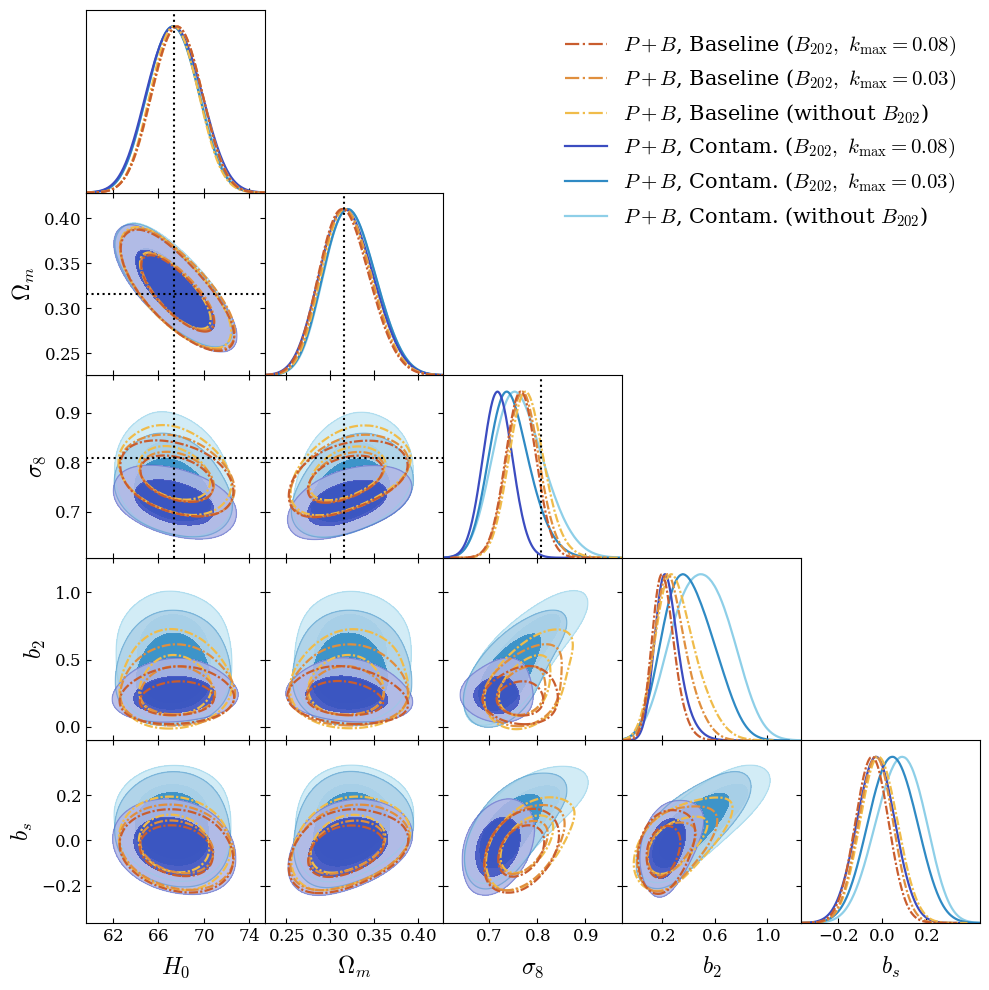

In [14]:
plot_params = params
contour_lws = 1.6
contour_colors = [
    "#8ECFE8",  # light cyan-blue
    "#2F8AC4",  # clear medium blue
    "#3B4CC0",  
    "#F0BC4A",
    "#E08F3E",  
    "#C95D2E",  
]

g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(plot_params) * 2
g.settings.legend_fontsize = 16
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains1,
    plot_params,
    legend_loc='upper right',
    # legend_labels=labels1,
    contour_lws=contour_lws,
    contour_colors= contour_colors,
    contour_ls = ['-', '-', '-', '-.', '-.', '-.'],
    filled = [True, True, True, False, False, False]
)

# from plotting_tools import PLANCK_COSMOLOGY
true_values = PLANCK_COSMOLOGY
for i, pi in enumerate(plot_params[:3]):
    for j, pj in enumerate(plot_params[:i+1]):
        ax = g.subplots[i, j]
        ax.axvline(true_values[pj], c='k', ls=':', lw=1.5)
        if i != j:
            ax.axhline(true_values[pi], c='k', ls=':', lw=1.5)

from matplotlib.lines import Line2D
for leg in list(g.fig.legends):
    leg.remove()
# Desired legend order only
# chains1 order is: [set6, set5, set4, set3, set1]
legend_order = [5, 4, 3, 2, 1, 0]
# legend order becomes: [set1, set3, set4, set5, set6]
contour_ls = ['-', '-', '-', '-.', '-.', '-.']
legend_handles = [
    Line2D([0], [0], color=contour_colors[i], lw=contour_lws, ls=contour_ls[i],)
    for i in legend_order]

legend_labels = [labels1[i] for i in legend_order]
g.fig.legend(legend_handles, legend_labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=15,frameon=False,)

if save_fig == True:
    g.export(OVERLEAF_DIR+'/corner_QSO_Bk202.pdf')

In [28]:
chain2_set1 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-879d6599/chain_0.npy', r'$P+B$, Baseline ($B_{202}, \ k_{\rm{max}} = 0.08)$']
chain2_set2 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e13ffaa9/chain_0.npy', r'$P+B$, Contam. ($B_{202}, \ k_{\rm{max}} = 0.08)$']
chain2_set3 = [None, None]

In [ ]:
step = 2

chains = []
labels = []
params = ['H0', 'Omega_m', 'sigma8_m', 'QSO1.b1p', 'QSO1.b2p', 'QSO1.bsp'][:3]
# params += ['QSO1.X_FoG_pp', 'QSO1.alpha0p', 'QSO1.alpha2p', 'QSO1.sn0p', 'QSO1.sn2p']

for chain_fn, label in [chain2_set1, chain2_set2]:
    chain = Chain.load(chain_fn).remove_burnin(0.5)[::step]
    chain = chain.to_getdist(params=params, settings=analysis_settings)
    chains.append(chain)
    labels.append(label)
    param_names = chain.getParamNames()
    for param in param_names.names:
        label = PARAM_LABELS.get(param.name, param.name)
        if label.startswith('$') and label.endswith('$'):
            label = label[1:-1]
        if param.name.endswith('.b1p'):
            label = r'b_1'
        elif param.name.endswith('.b2p'):
            label = r'b_2'
        elif param.name.endswith('.bsp'):
            label = r'b_s'
        elif param.name.endswith('.X_FoG_pp'):
            label = r'X_{FoG}'
        elif param.name.endswith('.alpha0p'):
            label = r'\alpha_0'
        elif param.name.endswith('.alpha2p'):
            label = r'\alpha_2'
        elif param.name.endswith('.sn0p'):
            label = r's_{n,0}'
        elif param.name.endswith('.sn2p'):
            label = r's_{n,2}'
        param.label = label
    chain.setParamNames(param_names)

[003024.79]  07-07 14:41  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-879d6599/chain_0.npy.
Removed no burn in
[003024.83]  07-07 14:41  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e13ffaa9/chain_0.npy.
Removed no burn in


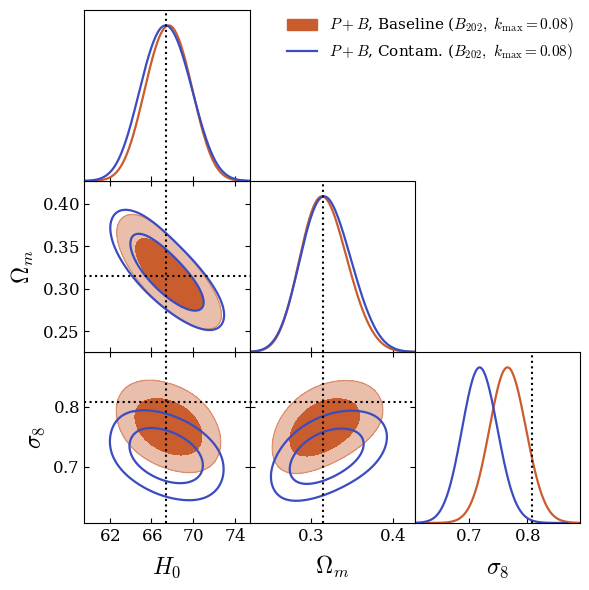

In [ ]:
plot_params = params

contour_colors = [
    "#C95D2E",  # burnt orange / vermilion
    "#3B4CC0",  # violet / indigo, most important
]
contour_lws = [1.6, 1.6, 1.6, 1.8, 1.8]

g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(plot_params) * 2
g.settings.legend_fontsize = 14
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    plot_params,
    legend_loc='upper right',
    legend_labels=labels,
    contour_lws=contour_lws,
    contour_colors= contour_colors,
    contour_ls = ['-', '-', '-', '-.', '-.'],
    filled = [True, False, False, False, False]
)

# from plotting_tools import PLANCK_COSMOLOGY
true_values = PLANCK_COSMOLOGY
for i, pi in enumerate(plot_params[:3]):
    for j, pj in enumerate(plot_params[:i+1]):
        ax = g.subplots[i, j]
        ax.axvline(true_values[pj], c='k', ls=':', lw=1.5)
        if i != j:
            ax.axhline(true_values[pi], c='k', ls=':', lw=1.5)

if save_fig == True:
    g.export(OVERLEAF_DIR+'/corner_QSO_Corr.pdf')

In [24]:

fn1_fixed_ns = ['/pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_clean/cosmo-base_ns-fixed_QSO1-S2+QSO1-S3-896c24a9/chain_0.npy', r'$P+B$, YD fixed ns ($B_{202}, \ k_{\rm{max}} = 0.08)$']
fn2_fixed_ns = ['/pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_zerr_none/cosmo-base_ns-fixed_QSO1-S2+QSO1-S3-4a78fe8c/chain_0.npy', r'$P+B$, YD fixed ns Contam. ($B_{202}, \ k_{\rm{max}} = 0.08)$']
fn3_fixed_ns = ['/pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_zerr_pdf/cosmo-base_ns-fixed_QSO1-S2+QSO1-S3-4e8643a8/chain_0.npy', r'$P+B$, YD fixed ns Corr. ($B_{202}, \ k_{\rm{max}} = 0.08)$']


fn1_free_ns = ['/pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg_nsfree_gpu_v2/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_nsfree_gpu_v2_clean/cosmo-base_QSO1-S2+QSO1-S3-1fd39526/chain_0.npy', r'$P+B$, YD free ns ($B_{202}, \ k_{\rm{max}} = 0.08)$']
fn2_free_ns = ['/pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg_nsfree_gpu_v2/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_nsfree_gpu_v2_zerr_none/cosmo-base_QSO1-S2+QSO1-S3-bc5e765d/chain_0.npy', r'$P+B$, YD free ns Contam. ($B_{202}, \ k_{\rm{max}} = 0.08)$']
fn3_free_ns = ['/pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg_nsfree_gpu_v2/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_nsfree_gpu_v2_zerr_pdf/cosmo-base_QSO1-S2+QSO1-S3-a7c66717/chain_0.npy', r'$P+B$, YD free ns Corr ($B_{202}, \ k_{\rm{max}} = 0.08)$']

[000812.60]  07-10 00:17  Chain                        INFO     Loading /pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_clean/cosmo-base_ns-fixed_QSO1-S2+QSO1-S3-896c24a9/chain_0.npy.
Removed no burn in
[000812.62]  07-10 00:17  Chain                        INFO     Loading /pscratch/sd/z/zhang_yd/modtheory/chains/cutsky_mean25_vdg_nsfree_gpu_v2/folpsd_cutsky_abacushf_mean25_pk0p35_pk2p25_bk0p20_bk2p08_vdg_nsfree_gpu_v2_clean/cosmo-base_QSO1-S2+QSO1-S3-1fd39526/chain_0.npy.
Removed no burn in
[000812.63]  07-10 00:17  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-879d6599/chain_0.npy.


Removed no burn in


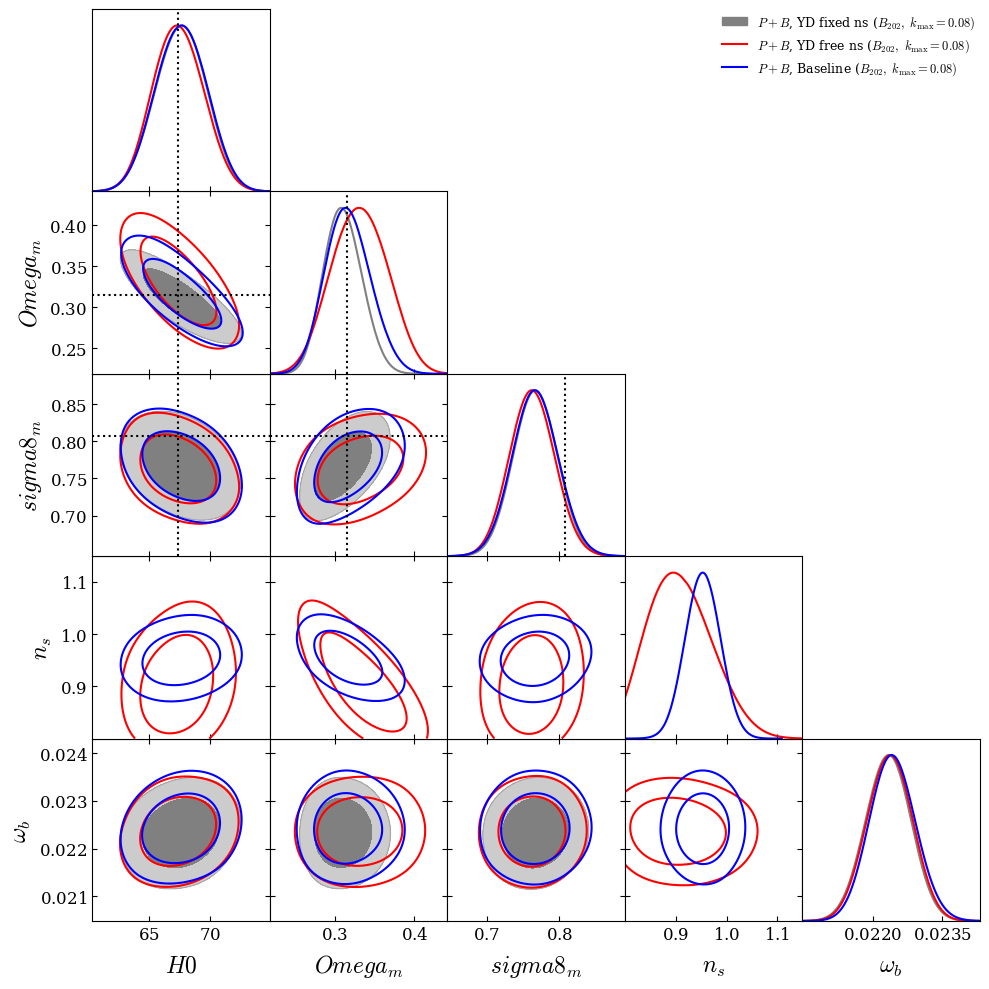

In [27]:
step = 2

chains = []
labels = []
params = ['H0', 'Omega_m', 'sigma8_m', 'n_s', 'omega_b']
# params += ['QSO1.b1p', 'QSO1.b2p', 'QSO1.bsp']
# params += ['QSO1.X_FoG_pp', 'QSO1.alpha0p', 'QSO1.alpha2p', 'QSO1.sn0p', 'QSO1.sn2p']

for chain_fn, label in [fn1_fixed_ns, fn1_free_ns, chain_set1]:
    chain = Chain.load(chain_fn).remove_burnin(0.5)[::step]
    chain = chain.to_getdist(params=params, settings=analysis_settings)
    chains.append(chain)
    labels.append(label)

plot_params = params

g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(plot_params) * 2
g.settings.legend_fontsize = 12
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    plot_params,
    legend_loc='upper right',
    legend_labels=labels,
    contour_lws=1.5,
    contour_ls = ['-', '-', '-', '-.', '-.'],
    filled = [True, False, False, False, False]
)

# from plotting_tools import PLANCK_COSMOLOGY
true_values = PLANCK_COSMOLOGY
for i, pi in enumerate(plot_params[:3]):
    for j, pj in enumerate(plot_params[:i+1]):
        ax = g.subplots[i, j]
        ax.axvline(true_values[pj], c='k', ls=':', lw=1.5)
        if i != j:
            ax.axhline(true_values[pi], c='k', ls=':', lw=1.5)

In [4]:
def load_folps_chain(path, label=None, burnin=0.5):
    names = open(path).readline().lstrip('#').split()
    data = np.loadtxt(path)
    # burnin can be a fraction, e.g. 0.5, or an integer number of rows
    if isinstance(burnin, float):
        n_burn = int(len(data) * burnin)
    else:
        n_burn = int(burnin)
    data = data[n_burn:]
    if label is None:
        label = os.path.basename(path).split('_cutsky')[0]
    if label is None: label = os.path.basename(path).split('_cutsky')[0]
    return MCSamples(samples=data[:, 2:], weights=data[:, 1], loglikes=-np.log(data[:, 0]),
                     names=names[2:], label=label,
                     settings={'mult_bias_correction_order': 1, 'smooth_scale_2D': 0.7, 'smooth_scale_1D': 0.7})

In [ ]:
folps_dir = '/global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/chains_mock_challenge/cutsky/folps_chains'
folps_LRG1 = [f'{folps_dir}/LRG1_folpsD_P02_0.35-0.25_B02_0.20-0.03_cutsky_lambdacdm.txt', 'LRG1_folpsD']
folps_LRG2 = [f'{folps_dir}/LRG2_folpsD_P02_0.35-0.25_B02_0.20-0.03_cutsky_lambdacdm.txt', 'LRG2_folpsD']
folps_LRG3 = [f'{folps_dir}/LRG3_folpsD_P02_0.35-0.25_B02_0.20-0.03_cutsky_lambdacdm.txt', 'LRG3_folpsD']

fid_LRG1 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2+LRG1-z0.4-0.6-mean25-S3-1bf14aa8/chain_0.npy', 'LRG1_Pk_0.35-0.25_Bk_0.2-0.03 (dk=0.01)']
fid_LRG2 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG2-z0.6-0.8-mean25-S2+LRG2-z0.6-0.8-mean25-S3-7c77f313/chain_0.npy', 'LRG2_Pk_0.35-0.25_Bk_0.2-0.03 (dk=0.01)']
fid_LRG3 = [None, 'LRG3_fid']

test_LRG1 = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2+LRG1-z0.4-0.6-mean25-S3-46913e7c/chain_0.npy', 'LRG1_Pk_0.30-0.30_Bk_0.2-0.08 (dk=0.01']

fid_LRG1_e  = ['/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-z0.4-0.6-mean25-S2+LRG1-z0.4-0.6-mean25-S3-3d52ae01/chain_0.npy', 'LRG1_Pk_0.35-0.25_Bk_0.2-0.03 (dk=0.005)']

compares = [folps_LRG1, fid_LRG1, test_LRG1]
# compares = [folps_LRG1, folps_LRG2, folps_LRG3, fid_LRG1, fid_LRG2, fid_LRG3]

# params = ['h', 'omega_cdm', 'logA', f'{tracer}.b1p', f'{tracer}.b2p', f'{tracer}.bsp']

In [ ]:
chains=[]
labels=[]

for fn, label in compares:
    if 'folps' in fn:
        chain = load_folps_chain(fn)
    else:
        chain = Chain.load(fn).remove_burnin(0.5)
        chain = chain.to_getdist(params=params, settings=analysis_settings)
    chains.append(chain)
    labels.append(label)

Removed no burn in
Removed no burn in
Removed no burn in


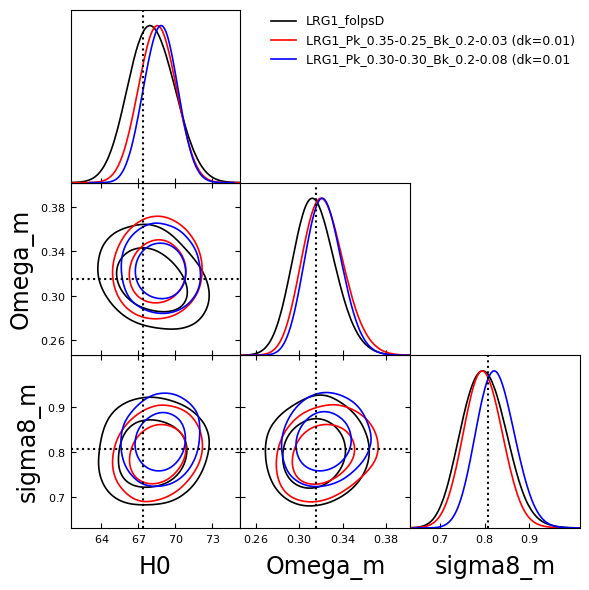

In [27]:
g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(params) * 2
g.settings.legend_fontsize = 12
g.settings.axes_labelsize = 20
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    params,
    legend_loc='upper right',
    legend_labels=labels,
    contour_lws=1.2,
    contour_ls = ['-', '-',  '-', '--', '--']
)

from plotting_tools import PLANCK_COSMOLOGY
true_values = PLANCK_COSMOLOGY
for i, pi in enumerate(params[:3]):
    for j, pj in enumerate(params[:i+1]):
        ax = g.subplots[i, j]
        ax.axvline(true_values[pj], c='k', ls=':', lw=1.5)
        if i != j:
            ax.axhline(true_values[pi], c='k', ls=':', lw=1.5)